# Temporal Convolutional Network for Retail Demand Forecasting

## Objective

This notebook implements a Temporal Convolutional Network (TCN) for
next-day retail demand forecasting.

The model receives the previous 28 days of demand and predicts demand
for the following day.

The TCN uses:

- Causal convolutions
- Dilated convolutions
- Residual connections
- ReLU activation
- Dropout regularization

The model is designed to capture temporal dependencies without recurrent
processing.

In [10]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

if 'google.colab' in sys.modules:
    BASE = Path("/content")
else:
    BASE = Path("..").resolve()

sys.path.insert(0, str(BASE / "src"))

In [11]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [12]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [13]:
import importlib
import data_splitting
import scaling
import sequence_generator

processed_path = BASE / "data" / "m5" / "processed"
results_path = BASE / "results"

sales_clean = pd.read_csv(processed_path / "sales_train_validation_clean.csv")

split = data_splitting.create_chronological_split(
    sales_clean, train_ratio=0.80, validation_ratio=0.10
)

scaler = scaling.fit_scaler_on_training_data(sales_clean, split["train"])
scaled_data = scaling.transform_sales_splits(sales_clean, split, scaler)

scaled_all = np.concatenate(
    [scaled_data["train"], scaled_data["validation"], scaled_data["test"]],
    axis=1
)

LOOKBACK = 28
train_end = split["train_days"]
validation_end = train_end + split["validation_days"]
test_end = validation_end + split["test_days"]

train_dataset = sequence_generator.RetailSequenceDataset(
    data=scaled_all, start_target=LOOKBACK, end_target=train_end, lookback=LOOKBACK
)
validation_dataset = sequence_generator.RetailSequenceDataset(
    data=scaled_all, start_target=train_end, end_target=validation_end, lookback=LOOKBACK
)
test_dataset = sequence_generator.RetailSequenceDataset(
    data=scaled_all, start_target=validation_end, end_target=test_end, lookback=LOOKBACK
)

print("Datasets recreated successfully.")

Datasets recreated successfully.


In [14]:
from torch.utils.data import DataLoader

BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [15]:
import importlib
import tcn

importlib.reload(tcn)

from tcn import TCNRegressor

model = TCNRegressor(
    input_features=1,
    channels=(32, 32, 64, 64),
    kernel_size=3,
    dropout=0.2
)

model = model.to(device)

print(model)

TCNRegressor(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (activation1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (activation2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (residual): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
      (final_activation): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp1): Chomp1d()
      (activation1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp2): Chomp1d()
      (activation2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (residual): Identity()
      (final_activation): ReLU()
    )
    (2): T

Your architecture is:

```
Input
28 × 1
 │
 ▼
Conv1D
32 channels
kernel = 3
dilation = 1
 │
 ▼
Residual Block
32 channels
dilation = 2
 │
 ▼
Residual Block
64 channels
dilation = 4
 │
 ▼
Residual Block
64 channels
dilation = 8
 │
 ▼
Last temporal representation
64
 │
 ▼
Dense
32
 │
 ▼
ReLU
 │
 ▼
Dropout
 │
 ▼
Dense
1
 │
 ▼
Prediction
```

The dilation pattern is:

`1 → 2 → 4 → 8`

which expands the receptive field without requiring a very deep network.

In [7]:
X_batch, y_batch = next(
    iter(train_loader)
)

X_batch = X_batch.to(device)

with torch.no_grad():
    predictions = model(
        X_batch
    )

print(
    "Input shape:",
    X_batch.shape
)

print(
    "Prediction shape:",
    predictions.shape
)

Input shape: torch.Size([256, 28, 1])
Prediction shape: torch.Size([256])


In [8]:
def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

parameter_count = count_parameters(model)

print(
    "Trainable parameters:",
    parameter_count
)

Trainable parameters: 56993


In [9]:
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5
EPOCHS = 30
PATIENCE = 5

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [10]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    total_samples = 0

    for X, y in loader:

        X = X.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        predictions = model(X)

        loss = criterion(
            predictions,
            y
        )

        loss.backward()

        optimizer.step()

        batch_size = X.size(0)

        running_loss += (
            loss.item() *
            batch_size
        )

        total_samples += batch_size

    return running_loss / total_samples

In [11]:
def evaluate_loss(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    total_samples = 0

    with torch.no_grad():

        for X, y in loader:

            X = X.to(
                device,
                non_blocking=True
            )

            y = y.to(
                device,
                non_blocking=True
            )

            predictions = model(X)

            loss = criterion(
                predictions,
                y
            )

            batch_size = X.size(0)

            running_loss += (
                loss.item() *
                batch_size
            )

            total_samples += batch_size

    return running_loss / total_samples

In [12]:
import time

# --------------------------------------------------
# Recreate TCN from scratch
# --------------------------------------------------

model = TCNRegressor(
    input_features=1,
    channels=(32, 32, 64, 64),
    kernel_size=3,
    dropout=0.2
).to(device)

parameter_count = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", parameter_count)

LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5
EPOCHS = 30
PATIENCE = 5

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

best_validation_loss = float("inf")
patience_counter = 0

history = {
    "train_loss": [],
    "validation_loss": []
}

checkpoint_path = str(
    results_path / "tcn_best_model.pt"
)

training_start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    validation_loss = evaluate_loss(
        model,
        validation_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {validation_loss:.6f}"
    )

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss
        patience_counter = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "validation_loss": validation_loss,
                "parameters": parameter_count
            },
            checkpoint_path
        )

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print("Early stopping triggered.")
            break

training_time = time.perf_counter() - training_start

print()
print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

Trainable parameters: 56993
Epoch 01/30 | Train Loss: 0.314537 | Validation Loss: 0.272254
Epoch 02/30 | Train Loss: 0.309310 | Validation Loss: 0.268629
Epoch 03/30 | Train Loss: 0.309668 | Validation Loss: 0.273154
Epoch 04/30 | Train Loss: 0.311033 | Validation Loss: 0.271739
Epoch 05/30 | Train Loss: 0.310374 | Validation Loss: 0.274322
Epoch 06/30 | Train Loss: 0.312092 | Validation Loss: 0.272657
Epoch 07/30 | Train Loss: 0.312837 | Validation Loss: 0.275934
Early stopping triggered.

Training time: 11208.87 seconds
Training time: 186.81 minutes


In [13]:
history_df = pd.DataFrame({
    "epoch": range(1, len(history["train_loss"]) + 1),
    "train_loss": history["train_loss"],
    "validation_loss": history["validation_loss"]
})

metrics_dir = results_path / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

history_path = str(metrics_dir / "tcn_training_history.csv")

history_df.to_csv(
    history_path,
    index=False
)

print("Saved:", history_path)

Saved: E:\dl-assignment\results\metrics\tcn_training_history.csv


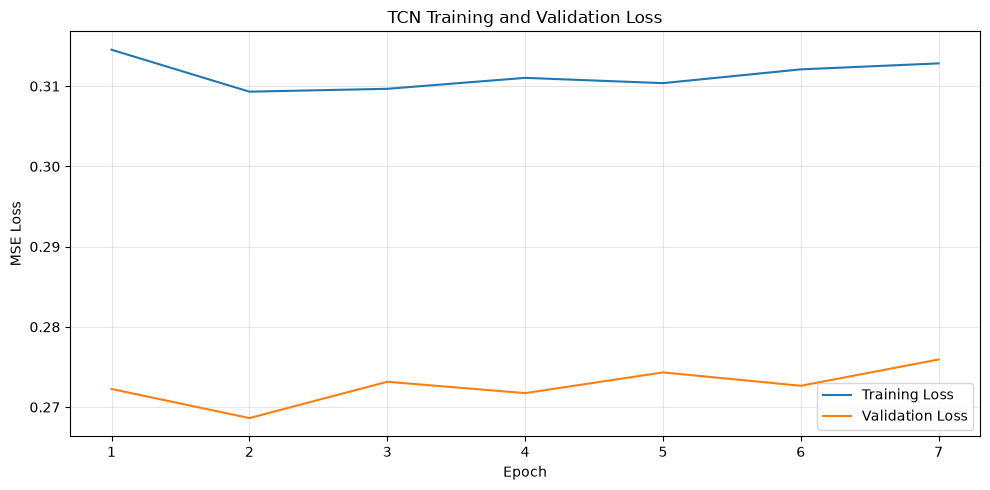

Saved: E:\dl-assignment\results\plots\tcn_learning_curve.png


In [14]:
import matplotlib.pyplot as plt
from pathlib import Path

plots_dir = results_path / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("TCN Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plot_path = str(plots_dir / "tcn_learning_curve.png")

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", plot_path)

In [15]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["validation_loss"])
print("Parameters:", parameter_count)
print(f"Training time: {training_time / 60:.2f} minutes")

Best epoch: 2
Best validation loss: 0.268628873648871
Parameters: 56993
Training time: 186.81 minutes


In [16]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation loss:",
    checkpoint["validation_loss"]
)

Best epoch: 2
Best validation loss: 0.268628873648871


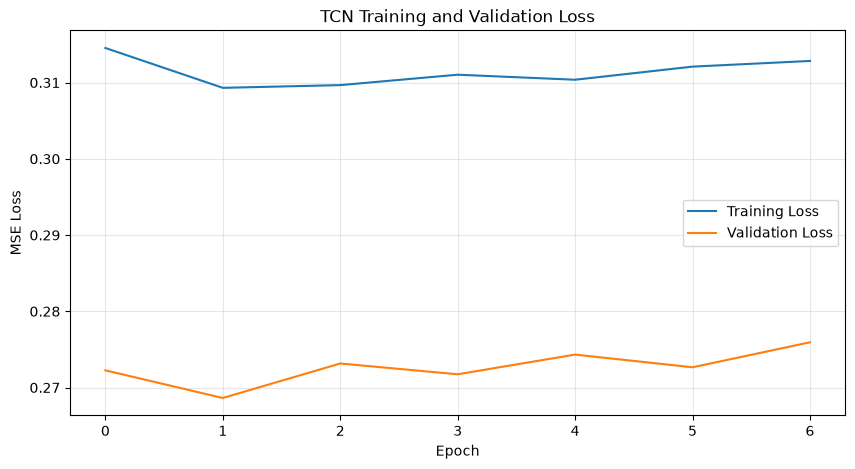

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["validation_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("TCN Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

This becomes one of your report figures.

You will later discuss:

* convergence
* overfitting
* underfitting
* training stability
* validation behavior

based on the actual curve.

---

## Important issue with the M5 scale

Because the model is trained on standardized demand, the loss currently represents error in **scaled demand units**.

For your final evaluation, we need to convert predictions back to original demand units before calculating:

    MAE
    MSE
    RMSE
    R²

That evaluation utility should be shared between TCN and Transformer rather than duplicating it.

So don't create the final evaluation implementation yet.

## Post-Training Inspection

Check the loaded best model to ensure it is correctly restoring from Epoch 5 (or the best epoch) and check memory usage.

In [18]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
    # Note: if using CUDA and the model was saved on CUDA, map_location=device handles it.
)

model.load_state_dict(checkpoint["model_state_dict"])

print("Best epoch:", checkpoint["epoch"])
print(
    "Best validation loss:",
    checkpoint["validation_loss"]
)

print(
    "Model parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

Best epoch: 2
Best validation loss: 0.268628873648871
Model parameters: 56993


In [19]:
if torch.cuda.is_available():
    print(
        "Allocated GPU memory:",
        round(
            torch.cuda.memory_allocated() / 1024**3,
            2
        ),
        "GB"
    )

    print(
        "Reserved GPU memory:",
        round(
            torch.cuda.memory_reserved() / 1024**3,
            2
        ),
        "GB"
    )

Allocated GPU memory: 0.02 GB
Reserved GPU memory: 0.08 GB


## TCN Test Evaluation

Evaluate the saved TCN on the **completely unseen test period** and calculate:

**MAE, MSE, RMSE, and R² in the original sales-demand scale.**

In [16]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------
# 1. Load the best TCN checkpoint
# --------------------------------------------------

checkpoint_path = str(results_path / "tcn_best_model.pt")

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best TCN checkpoint")
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["validation_loss"])

Loaded best TCN checkpoint
Best epoch: 2
Best validation loss: 0.268628873648871


In [17]:
# --------------------------------------------------
# 2. Generate predictions on the unseen test set
# --------------------------------------------------

test_predictions = []
test_targets = []

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device, non_blocking=True)

        predictions = model(X)

        test_predictions.append(
            predictions.cpu().numpy()
        )

        test_targets.append(
            y.numpy()
        )

test_predictions = np.concatenate(test_predictions)
test_targets = np.concatenate(test_targets)

print("Prediction shape:", test_predictions.shape)
print("Target shape:", test_targets.shape)

Prediction shape: (5854080,)
Target shape: (5854080,)


In [18]:
# --------------------------------------------------
# 3. Convert predictions back to original demand scale
# --------------------------------------------------

predictions_original = scaler.inverse_transform(
    test_predictions.reshape(-1, 1)
).ravel()

targets_original = scaler.inverse_transform(
    test_targets.reshape(-1, 1)
).ravel()

print("Original prediction range:",
      predictions_original.min(),
      predictions_original.max())

print("Original target range:",
      targets_original.min(),
      targets_original.max())

Original prediction range: -0.26073194 211.71599
Original target range: 0.0 323.0


In [ ]:
# --------------------------------------------------
# 4. Calculate test metrics
# --------------------------------------------------

mae = mean_absolute_error(
    targets_original,
    predictions_original
)

mse = mean_squared_error(
    targets_original,
    predictions_original
)

rmse = np.sqrt(mse)

r2 = r2_score(
    targets_original,
    predictions_original
)

print("\nTCN Test Results")
print("-------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


TCN Test Results
-------------------------
MAE  : 0.9485
MSE  : 4.1473
RMSE : 2.0365
R²   : 0.6669


In [ ]:
# --------------------------------------------------
# 5. Save TCN metrics
# --------------------------------------------------

metrics = pd.DataFrame([{
    "model": "TCN",
    "best_epoch": checkpoint["epoch"],
    "validation_mse": checkpoint["validation_loss"],
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2,
    "parameters": parameter_count,
    "training_time_seconds": training_time,
    "training_time_minutes": training_time / 60
}])

metrics_dir = results_path / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

metrics_path = str(metrics_dir / "tcn_metrics.csv")

metrics.to_csv(
    metrics_path,
    index=False
)

print("Saved:", metrics_path)

NameError: name 'parameter_count' is not defined

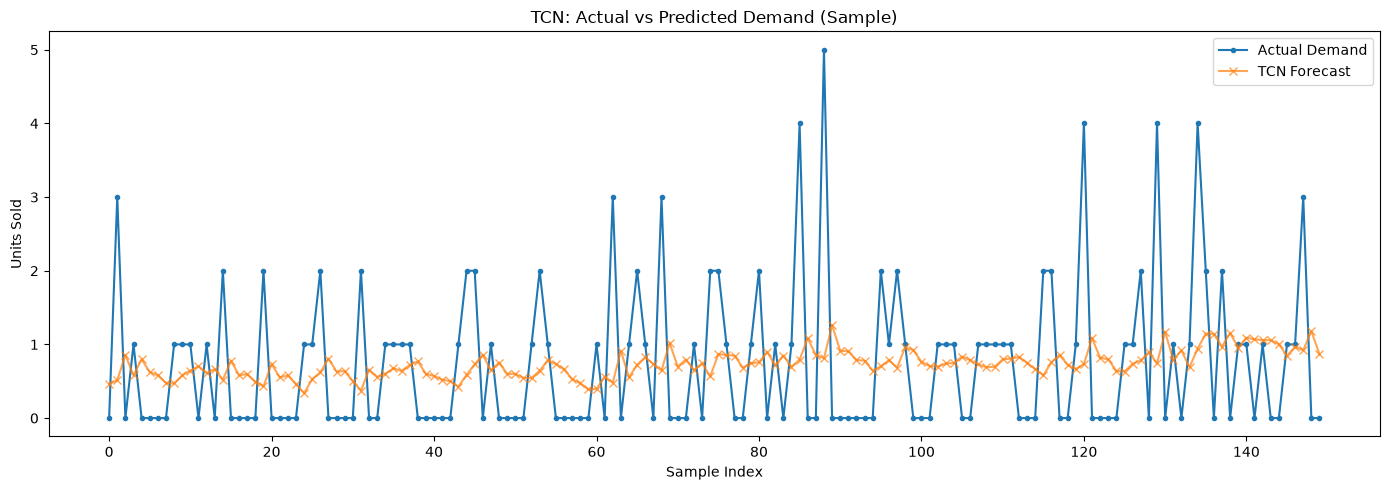

Saved TCN forecast examples to: E:\dl-assignment\results\figures\tcn_forecast_examples.png


In [21]:
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = results_path / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 5))
# Plot the first 150 test samples as an example
plt.plot(targets_original[:150], label='Actual Demand', marker='.')
plt.plot(predictions_original[:150], label='TCN Forecast', marker='x', alpha=0.7)
plt.title('TCN: Actual vs Predicted Demand (Sample)')
plt.xlabel('Sample Index')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()

plot_path = str(figures_dir / "tcn_forecast_examples.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print("Saved TCN forecast examples to:", plot_path)
